In [2]:
import os
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D,Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

encoder.fit([[0], [1]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequent

In [11]:
dataset_path = r"C:\Users\HP\Desktop\python basics\brain_tumor_dataset"

# This cell updates resultlist for images with Tumor
data=[]
paths=[]
result=[]
for r,d,f in os.walk(r"C:\Users\HP\Desktop\python basics\brain_tumor_dataset/yes"):
    for file in f:
        if '.jpg' in file:
            paths.append(os.path.join(r,file)) 


for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img = np.array(img, dtype=np.float32) / 255.0
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[0]]).toarray()[0])




#This cell updates result list for images without tumor 
paths=[]
for r,d,f in os.walk(r"C:\Users\HP\Desktop\python basics\brain_tumor_dataset/no"):
    for file in f:
        if '.jpg' in file:
            paths.append(os.path.join(r,file)) 


for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img = np.array(img, dtype=np.float32) / 255.0
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[1]]).toarray()[0])

In [12]:
data=np.array(data)
data.shape

(139, 128, 128, 3)

In [5]:
print(f'Total number of images we have:{len(data)}')


Total number of images we have:139


In [13]:
result = np.array(result)

print("Images:", data.shape)
print("Labels:", result.shape)

Images: (139, 128, 128, 3)
Labels: (139, 2)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data, result, test_size=0.2, shuffle= True,random_state=0)
print(f'Number of images in Training data:{len(x_train)}')
print(f'Number of images in Test data:{len(x_test)}')

Number of images in Training data:111
Number of images in Test data:28


In [21]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(2,2), input_shape=(128,128,3), padding='Same'))
model.add(Conv2D(32,kernel_size=(2,2), activation='relu', padding='Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add (Dropout(0.25))
model.add(Conv2D(64,kernel_size=(2,2), activation='relu', padding='Same'))
model.add(Conv2D(64,kernel_size=(2,2), activation='relu', padding='Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add (Dropout(0.25))

model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))
model.compile(loss="categorical_crossentropy", optimizer='Adamax', metrics=['accuracy'])
print(model.summary())




Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,585,602 (128.12 MB)

 Trainable params: 33,585,410 (128.12 MB)

 Non-trainable params: 192 (768.00 B)

None


In [22]:
history=model.fit(x_train, y_train, epochs=30, batch_size=40, verbose=1, validation_data=(x_test, y_test))

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 5s/step - accuracy: 0.5405 - loss: 32.4078 - val_accuracy: 0.7143 - val_loss: 45.8038
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6486 - loss: 21.2590 - val_accuracy: 0.6071 - val_loss: 63.3506
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.7928 - loss: 9.7112 - val_accuracy: 0.5000 - val_loss: 120.7542
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.7117 - loss: 13.9567 - val_accuracy: 0.5357 - val_loss: 65.1761
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.8739 - loss: 3.6615 - val_accuracy: 0.6429 - val_loss: 21.3890
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.8108 - loss: 5.4629 - val_accuracy: 0.7143 - val_loss: 25.2534
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.8919 - loss: 1.5040 - val_accuracy: 0.6429 - val_loss: 38.4419
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.9279 - loss: 0.5528 - val_accuracy: 0.6429 - val_loss: 43.5462
Ep

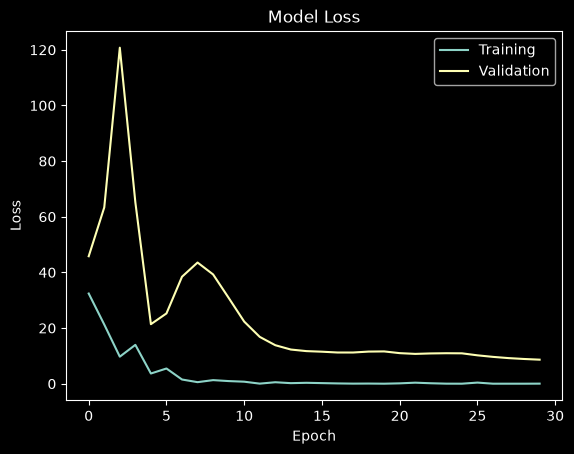

In [23]:
#Plot the Training Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

In [24]:
#Test the model#
def names(number):
    if number==0:
        return ('it is a tumor')
    else:
        return('it is not a tumor')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
100.00% Confidence - This is it is not a tumor


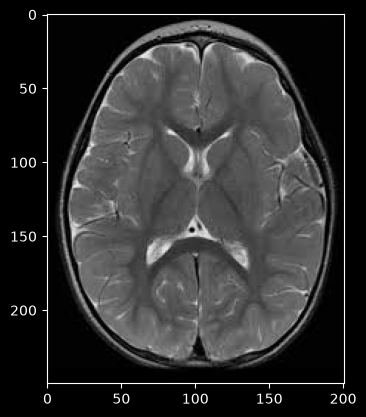

In [31]:
from matplotlib.pyplot import imshow
from PIL import Image
import numpy as np

img = Image.open(
    r"C:\Users\HP\Desktop\python basics\brain_tumor_dataset\no\N5.jpg"
)

x = np.array(img.resize((128, 128)))

# Normalize pixel values
x = x / 255.0

# Add batch dimension
x = x.reshape(1, 128, 128, 3)

# Prediction
res = model.predict(x)

classification = np.argmax(res[0])

imshow(img)

print(
    f"{res[0][classification] * 100:.2f}% Confidence - This is {names(classification)}"
)

100.0% Confidence This Isit is a tumor


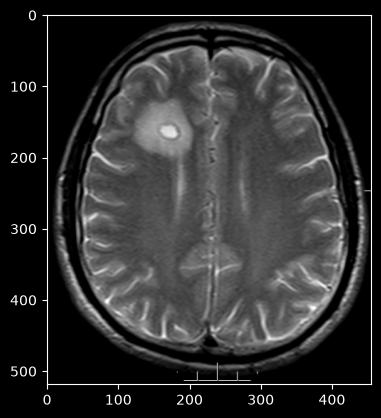

In [32]:
from matplotlib.pyplot import imshow
img=Image.open (r"C:\Users\HP\Desktop\python basics\brain_tumor_dataset/yes/Y3.jpg")
x=np.array(img.resize((128,128)))
x=x.reshape(1,128,128,3)
res=model.predict_on_batch(x)
classification=np.where(res==np.amax(res))[1] [0]
imshow(img)
print(str(res[0] [classification]*100)+'% Confidence This Is'+names (classification))

In [20]:
model.save("cnn_model.keras")

In [30]:
print("Total images:", len(data))
print("Training images:", len(x_train))
print("Test images:", len(x_test))

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

print("Training labels:", y_train.shape)
print("Test labels:", y_test.shape)


Total images: 139
Training images: 111
Test images: 28
Training shape: (111, 128, 128, 3)
Test shape: (28, 128, 128, 3)
Training labels: (111, 2)
Test labels: (28, 2)
